# Genesis TPS Sizing — Material Comparison

Sizing the thermal protection system for the Genesis Sample Return Capsule using `reentrykit`'s Level 1 sizing. Demonstrates the simulator's ability to compare different TPS materials for the same heating environment, illustrating the **thickness-vs-mass trade-off** that drives ablator selection in real spacecraft design.

## Mission Context

Genesis (2001-2004) was a NASA Discovery-class solar-wind sample-return mission. The Sample Return Capsule entered Earth's atmosphere on September 8, 2004, at 11.0 km/s — slightly slower than Stardust but still in the lunar-return velocity class.

## What This Notebook Compares

For the same Genesis trajectory and heating profile, we size two different TPS materials:

1. **PICA** (Phenolic Impregnated Carbon Ablator) — modern low-density ablator, used on Stardust, Orion, MSL, Dragon
2. **Carbon-Phenolic** (tape-wrapped, dense) — legacy heavy ablator, used on Pioneer-Venus, Galileo

Both target the same bondline limit (523 K). The comparison shows how material choice affects thickness AND mass — the actual engineering trade.

## Note on Genesis's Actual Heatshield

Genesis flew a **hybrid heatshield**, not a single material:
- Carbon-carbon at the forebody stagnation region
- Heavy carbon-phenolic in the deepest heating zone
- Graphite epoxy honeycomb with cork further back

Our analysis here treats the heatshield as a single homogeneous material for engineering comparison. The PICA case represents "what if Genesis had used the modern low-density ablator." The carbon-phenolic case approximates what was actually used in the deepest-heating zone.

## Approach

- Simulator: `reentrykit` 3-DOF non-rotating Earth, US1976 atmosphere
- Heating: Sutton-Graves convective + Tauber-Sutton radiative (combined)
- Sizing: Level 1 (1-D transient heat conduction, no ablation modeling)

Level 1 underpredicts thickness for ablators (no recession modeling), but the **relative comparison** between materials is engineering-meaningful.

## 2. Vehicle and Trajectory

Same Genesis configuration as notebook 05.

In [1]:
"""Genesis vehicle and trajectory."""

import numpy as np
import matplotlib.pyplot as plt

from reentrykit.trajectory import Vehicle, InitialState, simulate
from reentrykit.planet import EARTH_NON_ROTATING
from reentrykit.aerothermal import heating_history, HeatingResult
from reentrykit.tps import PICA, CARBON_PHENOLIC, size_tps, transient_bondline_temperature

# Genesis vehicle parameters
GENESIS_MASS = 225.0
GENESIS_DIAMETER = 1.52
GENESIS_AREA = np.pi * (GENESIS_DIAMETER / 2.0) ** 2
GENESIS_NOSE_RADIUS = 0.664
GENESIS_CD = 1.05

# Entry state
genesis_entry = InitialState(
    altitude=125_000.0, velocity=11_000.0,
    flight_path_angle=np.deg2rad(-8.0), heading=np.deg2rad(12.0),
    latitude=np.deg2rad(39.0), longitude=np.deg2rad(-125.0),
)

genesis_vehicle = Vehicle.from_mass_area_cd(
    mass=GENESIS_MASS, reference_area=GENESIS_AREA,
    drag_coefficient=GENESIS_CD, lift_to_drag_ratio=0.0, bank_angle=0.0,
    nose_radius=GENESIS_NOSE_RADIUS,
)

trajectory = simulate(genesis_vehicle, genesis_entry,
                       planet=EARTH_NON_ROTATING,
                       max_time=500.0, dt_output=0.1)

print(f"Genesis trajectory:")
print(f"  Flight time:    {trajectory.time[-1]:.1f} s")
print(f"  Final velocity: {trajectory.velocity[-1]:.1f} m/s")

Genesis trajectory:
  Flight time:    431.6 s
  Final velocity: 43.7 m/s


## 3. Heating Environment

Convective heating via Sutton-Graves and radiative heating via Tauber-Sutton. Both correlations are valid for Genesis (R_N = 0.664 m, well within Tauber-Sutton's R_N < 1 m unrestricted regime).

In [2]:
"""Compute total heating (convective + radiative)."""

heat = heating_history(trajectory, nose_radius=GENESIS_NOSE_RADIUS)

print(f"Genesis heating environment:")
print(f"  Peak convective: {heat.peak_convective_flux/1e6:.2f} MW/m²")
print(f"  Peak radiative:  {heat.peak_radiative_flux/1e6:.2f} MW/m²")
print(f"  Peak total:      {heat.peak_total_flux/1e6:.2f} MW/m²")
print(f"  Total heat load: {heat.total_integrated_load/1e6:.1f} MJ/m²")
print(f"  Radiative fraction at peak: "
      f"{heat.peak_radiative_flux/heat.peak_total_flux*100:.1f}%")

Genesis heating environment:
  Peak convective: 4.02 MW/m²
  Peak radiative:  0.93 MW/m²
  Peak total:      4.71 MW/m²
  Total heat load: 140.6 MJ/m²
  Radiative fraction at peak: 19.8%


## 4. Material Properties Comparison

In [3]:
"""Display PICA vs Carbon-Phenolic material properties."""

print(f"{'Property':<28} {'PICA':>15} {'Carbon-Phenolic':>20}")
print("-" * 75)
print(f"{'Density [kg/m³]':<28} "
      f"{PICA.density:>15.0f} "
      f"{CARBON_PHENOLIC.density:>20.0f}")
print(f"{'Thermal conductivity [W/m·K]':<28} "
      f"{PICA.thermal_conductivity:>15.2f} "
      f"{CARBON_PHENOLIC.thermal_conductivity:>20.2f}")
print(f"{'Specific heat [J/kg·K]':<28} "
      f"{PICA.specific_heat:>15.0f} "
      f"{CARBON_PHENOLIC.specific_heat:>20.0f}")
print(f"{'Ablation onset [K]':<28} "
      f"{PICA.max_surface_temperature:>15.0f} "
      f"{CARBON_PHENOLIC.max_surface_temperature:>20.0f}")
print(f"{'Bondline limit [K]':<28} "
      f"{PICA.max_bondline_temperature:>15.0f} "
      f"{CARBON_PHENOLIC.max_bondline_temperature:>20.0f}")

# Thermal diffusivity (key for transient response)
alpha_pica = PICA.thermal_conductivity / (PICA.density * PICA.specific_heat)
alpha_cp = CARBON_PHENOLIC.thermal_conductivity / (CARBON_PHENOLIC.density * CARBON_PHENOLIC.specific_heat)
print(f"{'Thermal diffusivity [m²/s]':<28} "
      f"{alpha_pica*1e6:>13.2f}e-6 "
      f"{alpha_cp*1e6:>18.2f}e-6")

Property                                PICA      Carbon-Phenolic
---------------------------------------------------------------------------
Density [kg/m³]                          270                 1450
Thermal conductivity [W/m·K]            0.20                 0.70
Specific heat [J/kg·K]                  1200                 1700
Ablation onset [K]                      3000                 3500
Bondline limit [K]                       523                  523
Thermal diffusivity [m²/s]            0.62e-6               0.28e-6


## 5. TPS Sizing for Both Materials

Total heating (convective + radiative) is used as input to the bisection sizing procedure for each material. The sizing finds minimum thickness keeping bondline ≤ 523 K.

In [4]:
"""Size both PICA and Carbon-Phenolic for Genesis heating."""

# Build sizing input using total heating
q_total = heat.total_flux
q_total_load = heat.total_load

heat_for_sizing = HeatingResult(
    time=heat.time,
    convective_flux=q_total, radiative_flux=heat.radiative_flux,
    total_flux=q_total,
    convective_load=q_total_load, radiative_load=heat.radiative_load,
    total_load=q_total_load,
    peak_convective_flux=heat.peak_total_flux,
    peak_radiative_flux=heat.peak_radiative_flux,
    peak_total_flux=heat.peak_total_flux,
    peak_total_flux_time=heat.peak_total_flux_time,
    peak_total_flux_altitude=heat.peak_total_flux_altitude,
    total_convective_load=heat.total_integrated_load,
    total_radiative_load=heat.total_radiative_load,
    total_integrated_load=heat.total_integrated_load,
)

# Size each material
sized_pica = size_tps(heat_for_sizing, PICA)
sized_cp = size_tps(heat_for_sizing, CARBON_PHENOLIC)

# Compare
print("=" * 80)
print(f"{'Genesis Level 1 Sizing: Material Comparison':^80}")
print("=" * 80)
print()
print(f"{'Material':<32} {'Thickness':>14} {'Surface T':>13} {'Mass/area':>14}")
print("-" * 80)
print(f"{'PICA':<32} "
      f"{sized_pica.required_thickness*1000:>11.1f} mm "
      f"{sized_pica.peak_surface_temperature:>10.0f} K "
      f"{PICA.density * sized_pica.required_thickness:>11.2f} kg/m²")
print(f"{'Carbon-Phenolic':<32} "
      f"{sized_cp.required_thickness*1000:>11.1f} mm "
      f"{sized_cp.peak_surface_temperature:>10.0f} K "
      f"{CARBON_PHENOLIC.density * sized_cp.required_thickness:>11.2f} kg/m²")

mass_pica = PICA.density * sized_pica.required_thickness
mass_cp = CARBON_PHENOLIC.density * sized_cp.required_thickness
print(f"\nThickness ratio (CP/PICA): "
      f"{sized_cp.required_thickness / sized_pica.required_thickness:.2f}")
print(f"Mass ratio (CP/PICA):      "
      f"{mass_cp/mass_pica:.2f}")

                  Genesis Level 1 Sizing: Material Comparison                   

Material                              Thickness     Surface T      Mass/area
--------------------------------------------------------------------------------
PICA                                    33.6 mm       3129 K        9.06 kg/m²
Carbon-Phenolic                         23.7 mm       3055 K       34.31 kg/m²

Thickness ratio (CP/PICA): 0.70
Mass ratio (CP/PICA):      3.79


## 6. Temperature Histories

Surface and bondline temperature time histories at the sized thickness for each material.

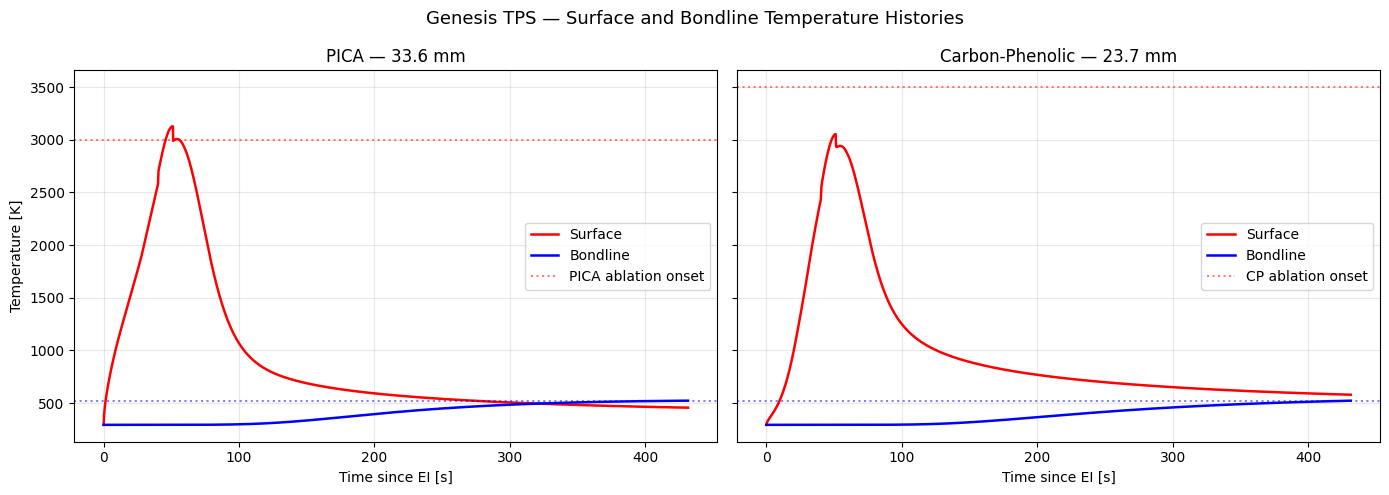

In [5]:
"""Plot surface and bondline temperatures for both materials."""

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# PICA panel
axes[0].plot(sized_pica.time, sized_pica.surface_temperature, 
             'r-', linewidth=1.8, label='Surface')
axes[0].plot(sized_pica.time, sized_pica.bondline_temperature,
             'b-', linewidth=1.8, label='Bondline')
axes[0].axhline(PICA.max_bondline_temperature, color='b', linestyle=':', alpha=0.5)
axes[0].axhline(PICA.max_surface_temperature, color='r', linestyle=':', alpha=0.5,
                label=f'PICA ablation onset')
axes[0].set_xlabel('Time since EI [s]')
axes[0].set_ylabel('Temperature [K]')
axes[0].set_title(f'PICA — {sized_pica.required_thickness*1000:.1f} mm')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CP panel
axes[1].plot(sized_cp.time, sized_cp.surface_temperature,
             'r-', linewidth=1.8, label='Surface')
axes[1].plot(sized_cp.time, sized_cp.bondline_temperature,
             'b-', linewidth=1.8, label='Bondline')
axes[1].axhline(CARBON_PHENOLIC.max_bondline_temperature, color='b', linestyle=':', alpha=0.5)
axes[1].axhline(CARBON_PHENOLIC.max_surface_temperature, color='r', linestyle=':', alpha=0.5,
                label=f'CP ablation onset')
axes[1].set_xlabel('Time since EI [s]')
axes[1].set_title(f'Carbon-Phenolic — {sized_cp.required_thickness*1000:.1f} mm')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Genesis TPS — Surface and Bondline Temperature Histories', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Discussion: Thickness vs Mass Trade

### Headline Engineering Result

| Material | Thickness | Mass per m² | Bondline T |
|---|---|---|---|
| **PICA** | 33.6 mm | 9.06 kg/m² | 522.6 K |
| **Carbon-Phenolic** | 23.7 mm | 34.31 kg/m² | 522.5 K |

Both materials successfully size to the same bondline limit (523 K). But:

- **CP is 30% thinner** than PICA (better cross-section)
- **CP is 3.8× heavier per unit area** than PICA (much worse mass)

### Why PICA Wins for Sample Return Missions

For a mass-constrained sample-return capsule, PICA's lower-density advantage outweighs CP's thinner cross-section. This is the engineering reason PICA replaced carbon-phenolic in modern Discovery-class missions:

- Stardust (2006): PICA, 58 mm, 15.7 kg/m² total mass
- Genesis (2004): hybrid carbon-carbon + carbon-phenolic, much heavier per area
- OSIRIS-REx (2023): PICA-class, lessons from Stardust applied
- Mars Science Laboratory (2012): PICA-similar low-density ablator

### The Underlying Physics

Two material properties drive the result:

1. **Thermal diffusivity** α = k/(ρ·c). PICA: 0.62×10⁻⁶ m²/s. CP: 0.28×10⁻⁶ m²/s. Lower diffusivity in CP means heat penetrates more slowly through the slab, so CP can be thinner to keep the bondline cool. (CP wins on thickness.)

2. **Volumetric heat capacity** ρ·c. PICA: 0.32×10⁶ J/m³K. CP: 2.47×10⁶ J/m³K. CP can absorb roughly 8× more heat per unit volume before its temperature rises significantly. This lets CP stay cooler internally with less material. (CP wins again on thickness.)

But both effects come from CP being **dense and heavy**. PICA wins on mass per area precisely because it's light, even though it must be thicker to compensate for higher diffusivity and lower heat capacity.

### The Mass-vs-Thickness Trade

For sample-return missions where every kg in the heatshield reduces science payload, **PICA's 3.8× mass advantage matters more than CP's 30% thinner cross-section.** This is the engineering reason PICA replaced carbon-phenolic for modern Discovery-class missions:

- Stardust (2006): PICA, 58 mm flown
- Mars Science Laboratory (2012): PICA-class low-density ablator
- OSIRIS-REx (2023): PICA-class with Stardust lessons applied

For missions where mass is less critical (interplanetary probes, planetary entry at extreme velocities), the heavier carbon-phenolic remains in use — Galileo and Pioneer-Venus used CP precisely because their entry environments demanded the highest possible volumetric heat capacity.
### Caveats

- **Level 1 sizing underpredicts ablator thickness** because mass loss is not modeled. Both PICA and CP are bounded by similar relative under-prediction, so the comparison remains valid even if the absolute numbers are conservative.
- **Constant material properties** assumed; both PICA and CP have temperature-dependent k and c that change significantly during ablation
- **Single-material analysis** — Genesis's actual hybrid heatshield (carbon-carbon + CP + cork) is not represented here

### What This Demonstrates

The simulator can:
1. Compute realistic radiative heating via Tauber-Sutton (R_N within validity)
2. Size multiple materials for the same heating environment
3. Make the engineering trade-off (thickness vs mass) quantitatively visible

This is the kind of analysis a TPS materials engineer would do early in conceptual design.

## References

- Tauber, M. E., & Sutton, K. (1991). *Stagnation-Point Radiative Heating Relations for Earth and Mars Entries.* JSR 28(1), 40-42.
- Sutton, K., & Graves, R. A. (1971). *A General Stagnation-Point Convective-Heating Equation for Arbitrary Gas Mixtures.* NASA TR R-376.
- Park, C. (1990). *Nonequilibrium Hypersonic Aerothermodynamics.* Wiley-Interscience.
- Tran, H. K., et al. (1997). *Phenolic Impregnated Carbon Ablators (PICA) as thermal protection systems for discovery missions.* NASA TM-110440.
- Desai, P. N., & Lyons, D. T. (2008). *Entry, descent, and landing operations analysis for the Genesis entry capsule.* JSR 45(1), 27-32.